In [ ]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [ ]:
# Распаковываем данные WVS-7
unzip("F00011421-WVS_Cross-National_Wave_7_rds_v6_0.zip")

In [ ]:
# Давай нарисуем гистограмму - рейтинг стран по религиозности. Все диаграммы будем сохранять с осмысленным названием в формате png.

[1] "График успешно сохранен как 'country_religiosity_rating_wvs7.png'"


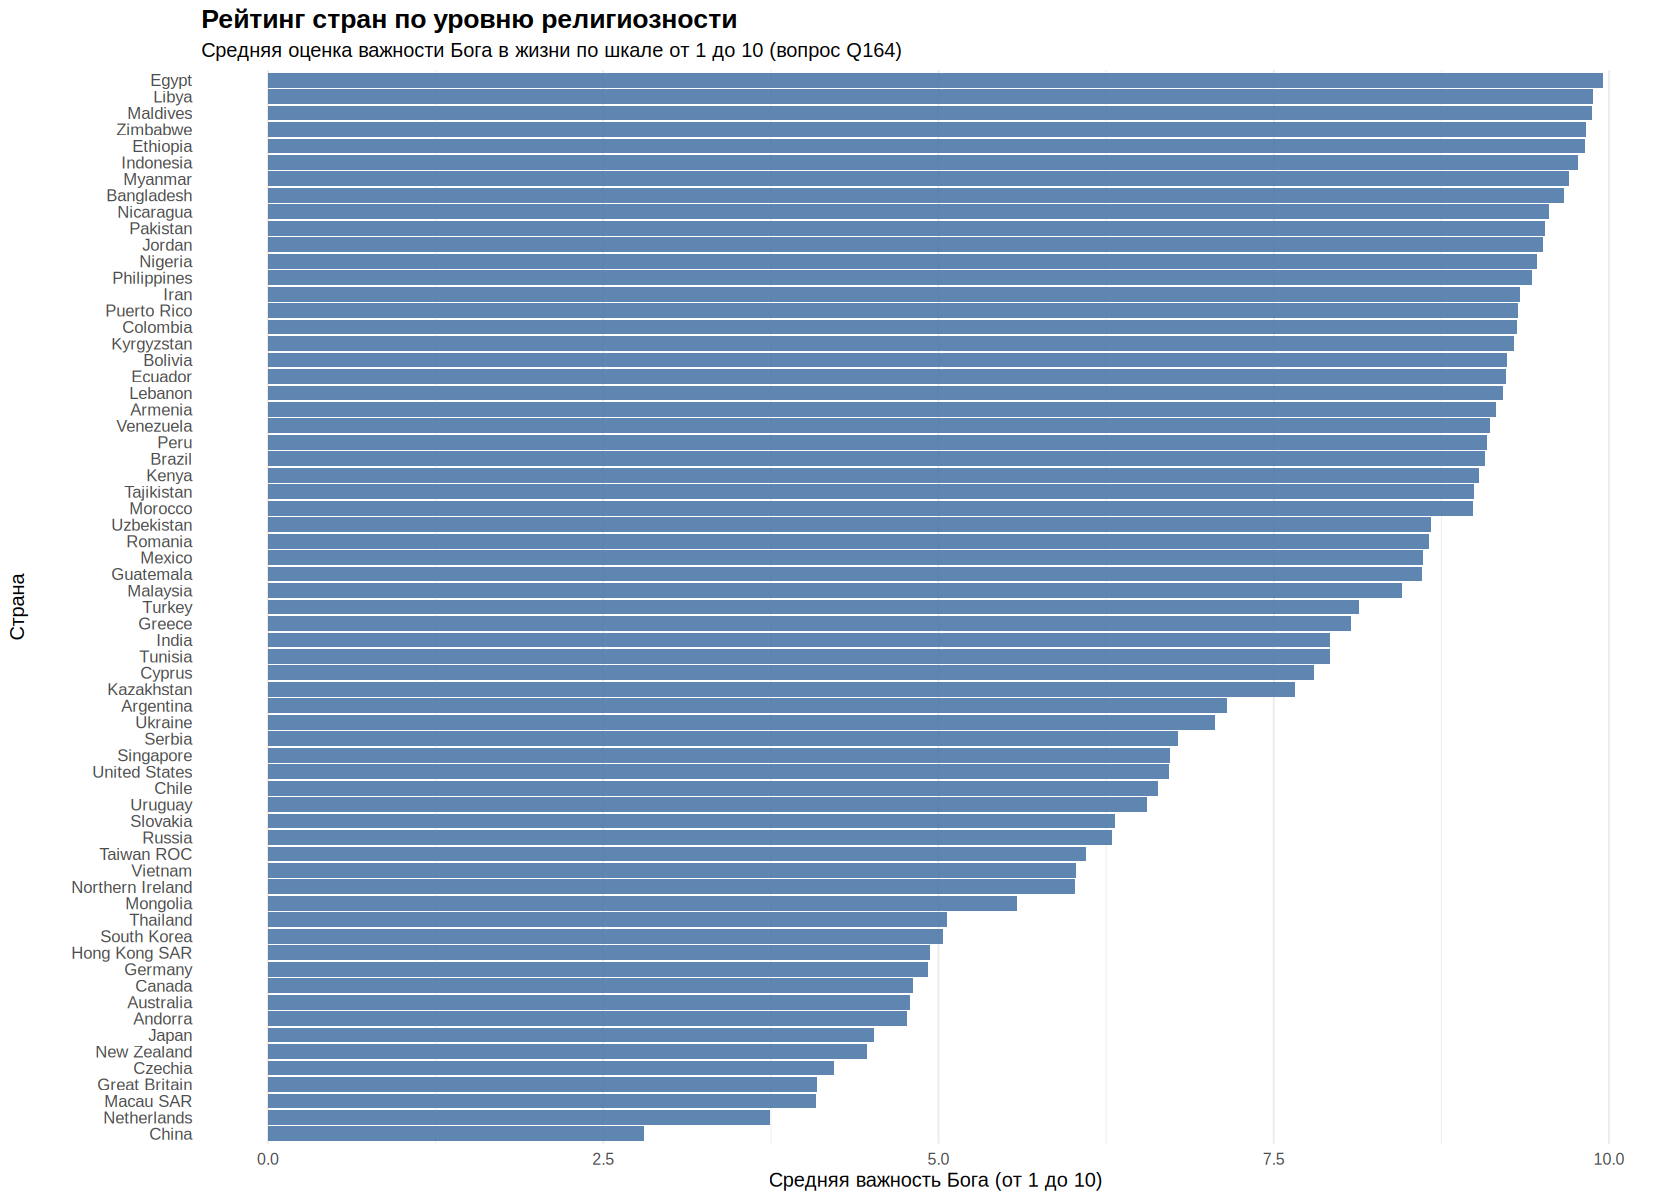

In [ ]:
library(dplyr)
library(haven)
library(ggplot2)

# 1. Подготовка данных по религиозности по всем странам
country_religiosity <- wvs7 %>%
  mutate(
    Country_Label = as_factor(B_COUNTRY),
    God_Importance = as.numeric(zap_labels(Q164))
  ) %>%
  # Исключаем пропущенные значения и некорректные коды ответов
  filter(!is.na(God_Importance) & God_Importance >= 1 & God_Importance <= 10) %>%
  group_by(Country_Label) %>%
  summarise(
    Mean_Religiosity = mean(God_Importance),
    N = n(),
    .groups = 'drop'
  ) %>%
  # Оставляем страны с репрезентативной выборкой
  filter(N >= 100) %>%
  arrange(desc(Mean_Religiosity))

# 2. Построение графика рейтинга
options(repr.plot.width = 14, repr.plot.height = 10)

p_relig_rating <- ggplot(country_religiosity, aes(x = reorder(Country_Label, Mean_Religiosity), y = Mean_Religiosity)) +
  geom_col(fill = "#4e79a7", alpha = 0.9) +
  coord_flip() +
  theme_minimal(base_size = 12) +
  labs(
    title = "Рейтинг стран по уровню религиозности",
    subtitle = "Средняя оценка важности Бога в жизни по шкале от 1 до 10 (вопрос Q164)",
    x = "Страна",
    y = "Средняя важность Бога (от 1 до 10)"
  ) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    axis.text.y = element_text(size = 10),
    panel.grid.major.y = element_blank()
  )

# Отобразим график
print(p_relig_rating)

# 3. Сохранение графика
ggsave(
  filename = "country_religiosity_rating_wvs7.png",
  plot = p_relig_rating,
  width = 14,
  height = 10,
  dpi = 300
)

print("График успешно сохранен как 'country_religiosity_rating_wvs7.png'")

In [ ]:
# Отличный результат. Теперь нужно выделить на этой диаграмме цветом три столбца: Сербия, Россия, Чехия.

Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”


[1] "Новый график успешно сохранен как 'country_religiosity_highlighted.png'"


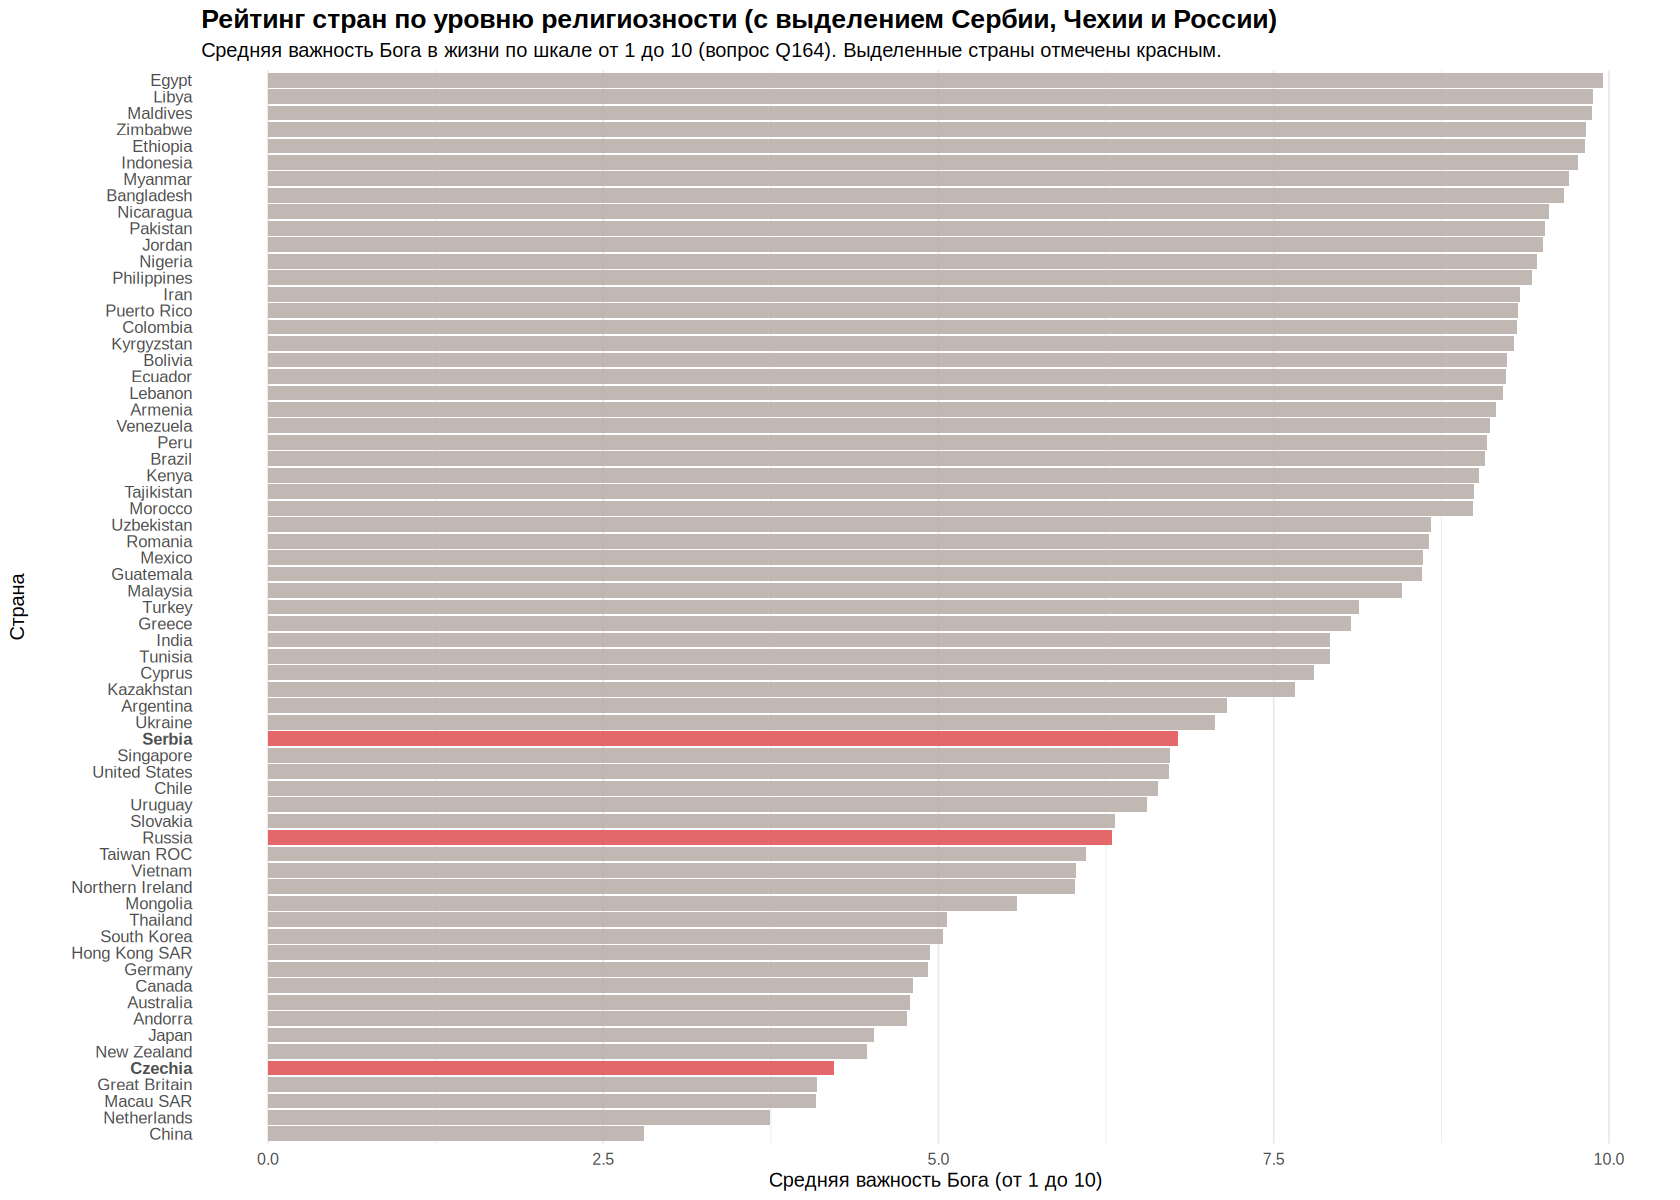

In [ ]:
library(dplyr)
library(haven)
library(ggplot2)

# 1. Подготовка данных с разметкой для выделения стран
country_relig_highlight <- wvs7 %>%
  mutate(
    Country_Label = as.character(as_factor(B_COUNTRY)),
    God_Importance = as.numeric(zap_labels(Q164))
  ) %>%
  filter(!is.na(God_Importance) & God_Importance >= 1 & God_Importance <= 10) %>%
  group_by(Country_Label) %>%
  summarise(
    Mean_Religiosity = mean(God_Importance),
    N = n(),
    .groups = 'drop'
  ) %>%
  filter(N >= 100) %>%
  # Добавляем категорию для подсветки нужных стран
  mutate(
    Highlight = case_when(
      Country_Label %in% c("Serbia", "Czechia", "Russian Federation", "Russia") ~ "Highlighted",
      TRUE ~ "Normal"
    )
  ) %>%
  arrange(desc(Mean_Religiosity))

# 2. Построение графика с выделением цветом
options(repr.plot.width = 14, repr.plot.height = 10)

p_highlight <- ggplot(country_relig_highlight, aes(x = reorder(Country_Label, Mean_Religiosity), y = Mean_Religiosity, fill = Highlight)) +
  geom_col(alpha = 0.9, show.legend = FALSE) +
  scale_fill_manual(values = c("Highlighted" = "#e15759", "Normal" = "#bab0ac")) +
  coord_flip() +
  theme_minimal(base_size = 12) +
  labs(
    title = "Рейтинг стран по уровню религиозности (с выделением Сербии, Чехии и России)",
    subtitle = "Средняя важность Бога в жизни по шкале от 1 до 10 (вопрос Q164). Выделенные страны отмечены красным.",
    x = "Страна",
    y = "Средняя важность Бога (от 1 до 10)"
  ) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    axis.text.y = element_text(size = 10, face = ifelse(levels(reorder(country_relig_highlight$Country_Label, country_relig_highlight$Mean_Religiosity)) %in% c("Serbia", "Czechia", "Russian Federation"), "bold", "plain")),
    panel.grid.major.y = element_blank()
  )

# Отобразим график
print(p_highlight)

# 3. Сохранение графика
ggsave(
  filename = "country_religiosity_highlighted.png",
  plot = p_highlight,
  width = 14,
  height = 10,
  dpi = 300
)

print("Новый график успешно сохранен как 'country_religiosity_highlighted.png'")

Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”


[1] "Обновленный двухпанельный график успешно сохранен как 'country_religiosity_highlighted.png'"


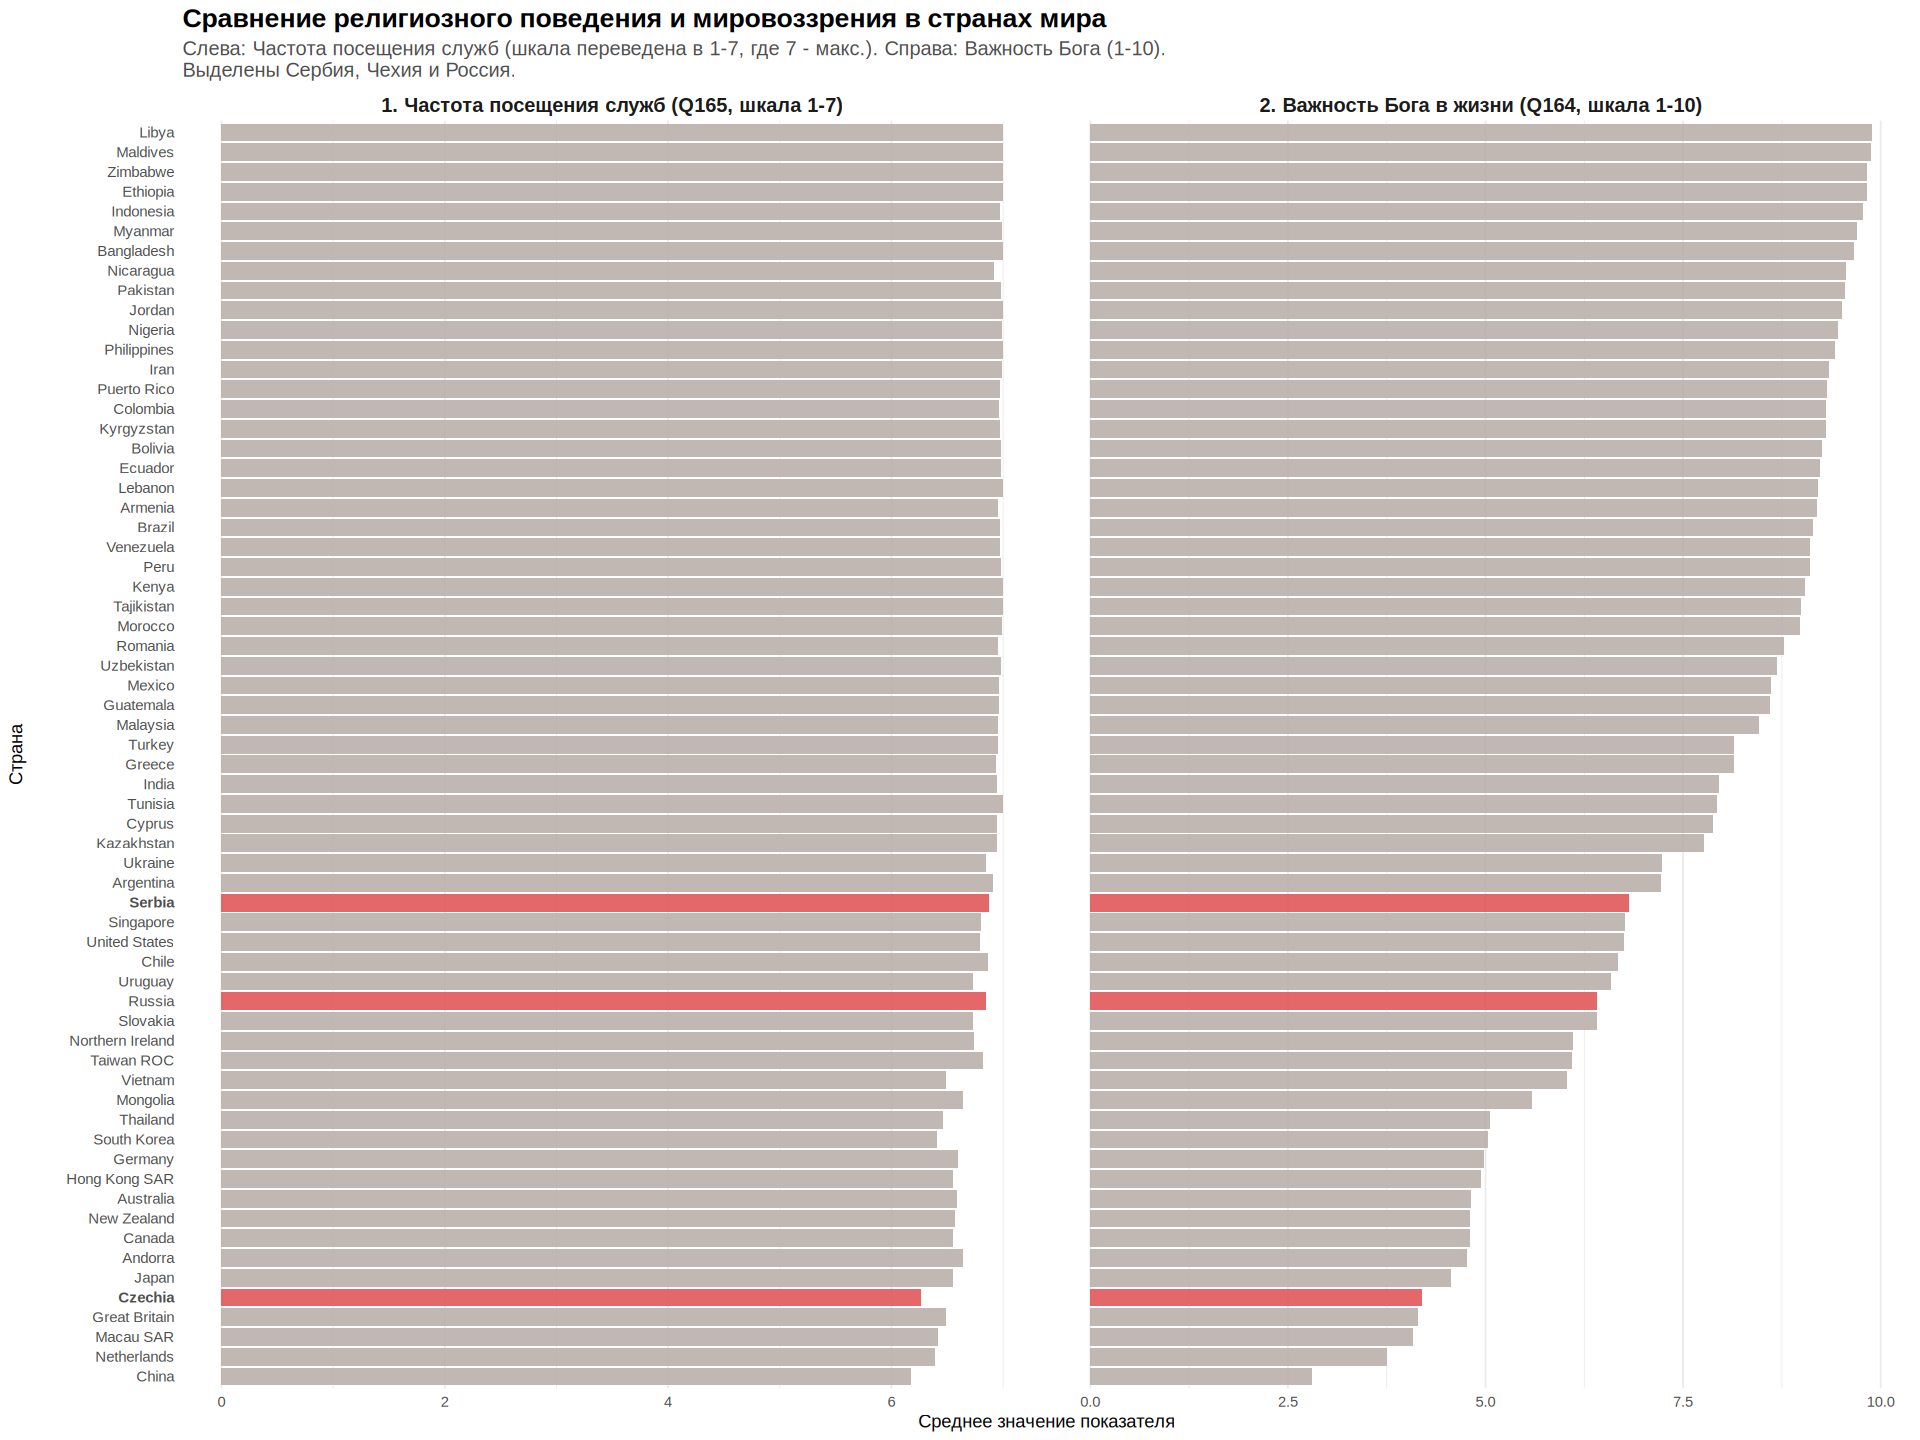

In [ ]:
library(dplyr)
library(haven)
library(ggplot2)
library(tidyr)

# 1. Подготовка объединенных данных по религиозности (Q164) и посещению служб (Q165)
country_data <- wvs7 %>%
  mutate(
    Country_Label = as.character(as_factor(B_COUNTRY)),
    # Важность Бога (1-10)
    God_Importance = as.numeric(zap_labels(Q164)),
    # Посещение служб (Q165): 1 - More than once a week, 7 - Practically never.
    # Инвертируем шкалу: 8 - Q165, чтобы большее число означало более частое посещение (7 - максимум, 1 - минимум)
    Church_Attendance = 8 - as.numeric(zap_labels(Q165))
  ) %>%
  filter(
    !is.na(God_Importance) & God_Importance >= 1 & God_Importance <= 10,
    !is.na(Church_Attendance) & Church_Attendance >= 1 & Church_Attendance <= 7
  ) %>%
  group_by(Country_Label) %>%
  summarise(
    Mean_Religiosity = mean(God_Importance),
    Mean_Attendance = mean(Church_Attendance),
    N = n(),
    .groups = 'drop'
  ) %>%
  filter(N >= 100) %>%
  mutate(
    Highlight = case_when(
      Country_Label %in% c("Serbia", "Czechia", "Russian Federation", "Russia") ~ "Highlighted",
      TRUE ~ "Normal"
    )
  )

# Для построения фасетного графика переведем данные в длинный формат (long format)
country_long <- country_data %>%
  pivot_longer(
    cols = c(Mean_Religiosity, Mean_Attendance),
    names_to = "Metric",
    values_to = "Value"
  ) %>%
  mutate(
    Metric_Label = case_when(
      Metric == "Mean_Attendance" ~ "1. Частота посещения служб (Q165, шкала 1-7)",
      Metric == "Mean_Religiosity" ~ "2. Важность Бога в жизни (Q164, шкала 1-10)"
    )
  )

# 2. Построение двухпанельного горизонтального столбчатого графика
options(repr.plot.width = 16, repr.plot.height = 12)

# Используем упорядочивание стран по уровню важности Бога
ordered_countries <- country_data %>%
  arrange(Mean_Religiosity) %>%
  pull(Country_Label)

country_long$Country_Label <- factor(country_long$Country_Label, levels = ordered_countries)

p_double_chart <- ggplot(country_long, aes(x = Country_Label, y = Value, fill = Highlight)) +
  geom_col(alpha = 0.9, show.legend = FALSE) +
  scale_fill_manual(values = c("Highlighted" = "#e15759", "Normal" = "#bab0ac")) +
  coord_flip() +
  facet_wrap(~Metric_Label, scales = "free_x") +
  theme_minimal(base_size = 11) +
  labs(
    title = "Сравнение религиозного поведения и мировоззрения в странах мира",
    subtitle = "Слева: Частота посещения служб (шкала переведена в 1-7, где 7 - макс.). Справа: Важность Бога (1-10).\nВыделены Сербия, Чехия и Россия.",
    x = "Страна",
    y = "Среднее значение показателя"
  ) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    plot.subtitle = element_text(size = 12, color = "gray30"),
    strip.text = element_text(face = "bold", size = 12),
    axis.text.y = element_text(size = 9, face = ifelse(ordered_countries %in% c("Serbia", "Czechia", "Russian Federation"), "bold", "plain")),
    panel.grid.major.y = element_blank()
  )

# Отобразим график
print(p_double_chart)

# 3. Перезаписываем и сохраняем исходный файл
ggsave(
  filename = "country_religiosity_highlighted.png",
  plot = p_double_chart,
  width = 16,
  height = 12,
  dpi = 300
)

print("Обновленный двухпанельный график успешно сохранен как 'country_religiosity_highlighted.png'")

In [ ]:
# Давай теперь агрегируем данные по странам и посмотрим средние значения по религиозности и доверию (вопрос о доверии людям). Представь результаты в виде диаграммы рассеяния: по x - религиозность, по y - доверие.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


[1] "Диаграмма рассеяния успешно сохранена как 'country_religiosity_vs_trust.png'"


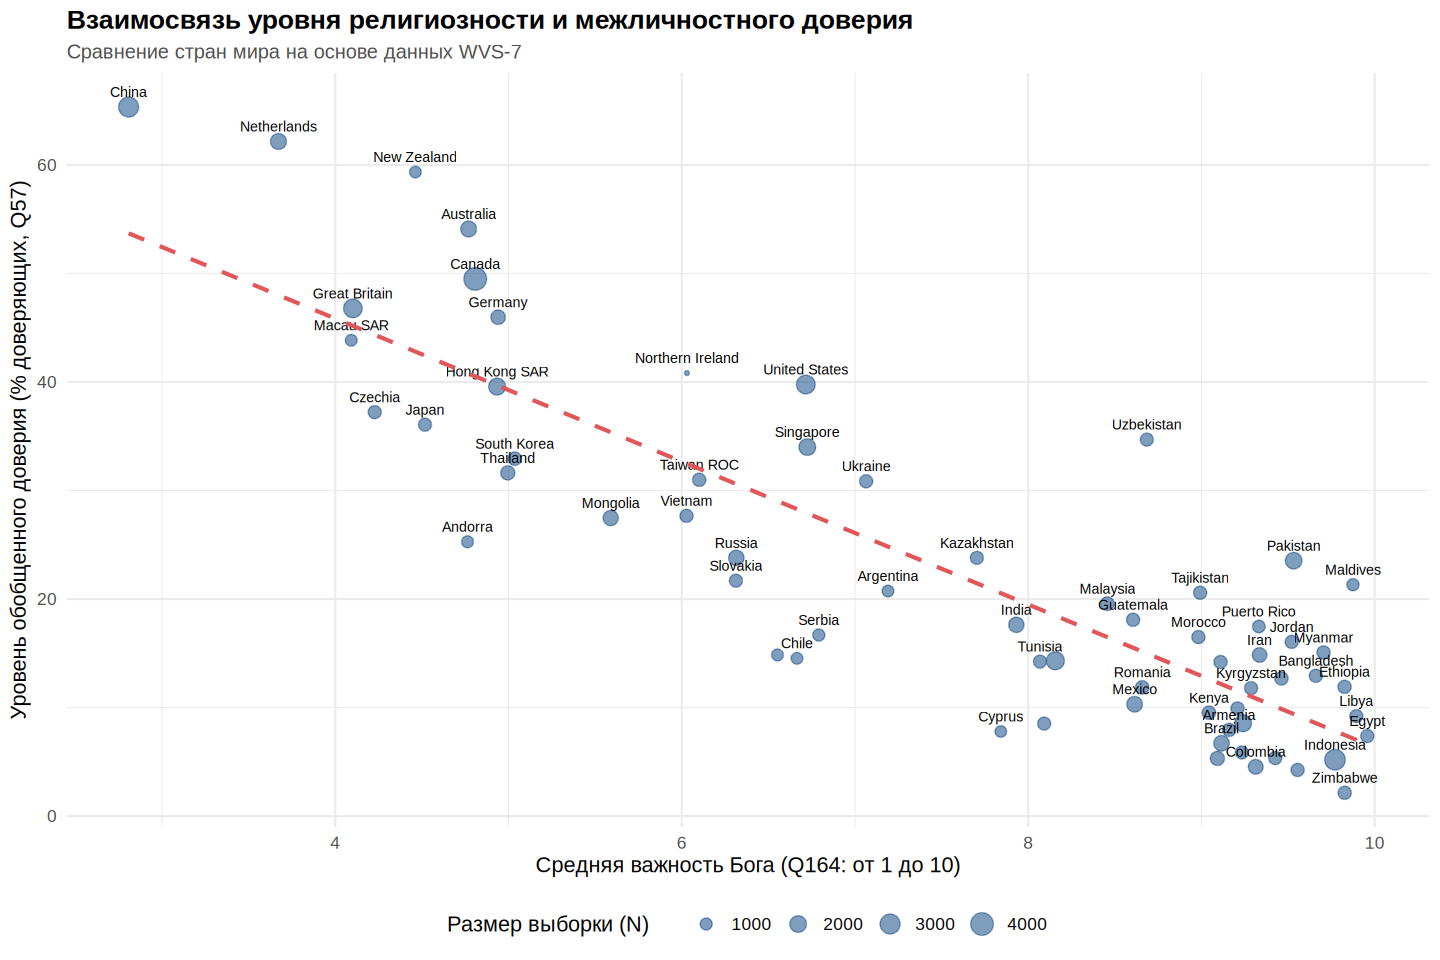

In [ ]:
library(dplyr)
library(haven)
library(ggplot2)

# 1. Агрегация данных по странам
country_comparison <- wvs7 %>%
  mutate(
    Country_Label = as.character(as_factor(B_COUNTRY)),
    God_Importance = as.numeric(zap_labels(Q164)),
    # Q57: 1 - Most people can be trusted, 2 - Need to be very careful
    # Считаем процент тех, кто доверяет людям
    Trust_Bin = ifelse(as.numeric(zap_labels(Q57)) == 1, 1, 0)
  ) %>%
  filter(
    !is.na(God_Importance) & God_Importance >= 1 & God_Importance <= 10,
    as.numeric(zap_labels(Q57)) > 0
  ) %>%
  group_by(Country_Label) %>%
  summarise(
    Mean_Religiosity = mean(God_Importance),
    Mean_Trust = mean(Trust_Bin) * 100,
    N = n(),
    .groups = 'drop'
  ) %>%
  # Фильтруем страны с репрезентативным числом ответов
  filter(N >= 100)

# 2. Построение диаграммы рассеяния
options(repr.plot.width = 12, repr.plot.height = 8)

p_scatter <- ggplot(country_comparison, aes(x = Mean_Religiosity, y = Mean_Trust)) +
  geom_point(aes(size = N), color = "#2b5c8f", alpha = 0.6) +
  # Используем стандартный geom_text с фильтрацией перекрытий
  geom_text(aes(label = Country_Label), size = 3, vjust = -1, check_overlap = TRUE) +
  geom_smooth(method = "lm", color = "#e15759", linetype = "dashed", se = FALSE) +
  theme_minimal(base_size = 13) +
  labs(
    title = "Взаимосвязь уровня религиозности и межличностного доверия",
    subtitle = "Сравнение стран мира на основе данных WVS-7",
    x = "Средняя важность Бога (Q164: от 1 до 10)",
    y = "Уровень обобщенного доверия (% доверяющих, Q57)",
    size = "Размер выборки (N)"
  ) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    plot.subtitle = element_text(size = 12, color = "gray30"),
    legend.position = "bottom"
  )

# Отобразим график
print(p_scatter)

# 3. Сохранение графика в PNG
ggsave(
  filename = "country_religiosity_vs_trust.png",
  plot = p_scatter,
  width = 12,
  height = 8,
  dpi = 300
)

print("Диаграмма рассеяния успешно сохранена как 'country_religiosity_vs_trust.png'")

In [ ]:
# Сделаем еще одну пузырьковую диаграмму: по x - религиозность, по y - самооценка материального благополучия, а размер точки - значимость семьи

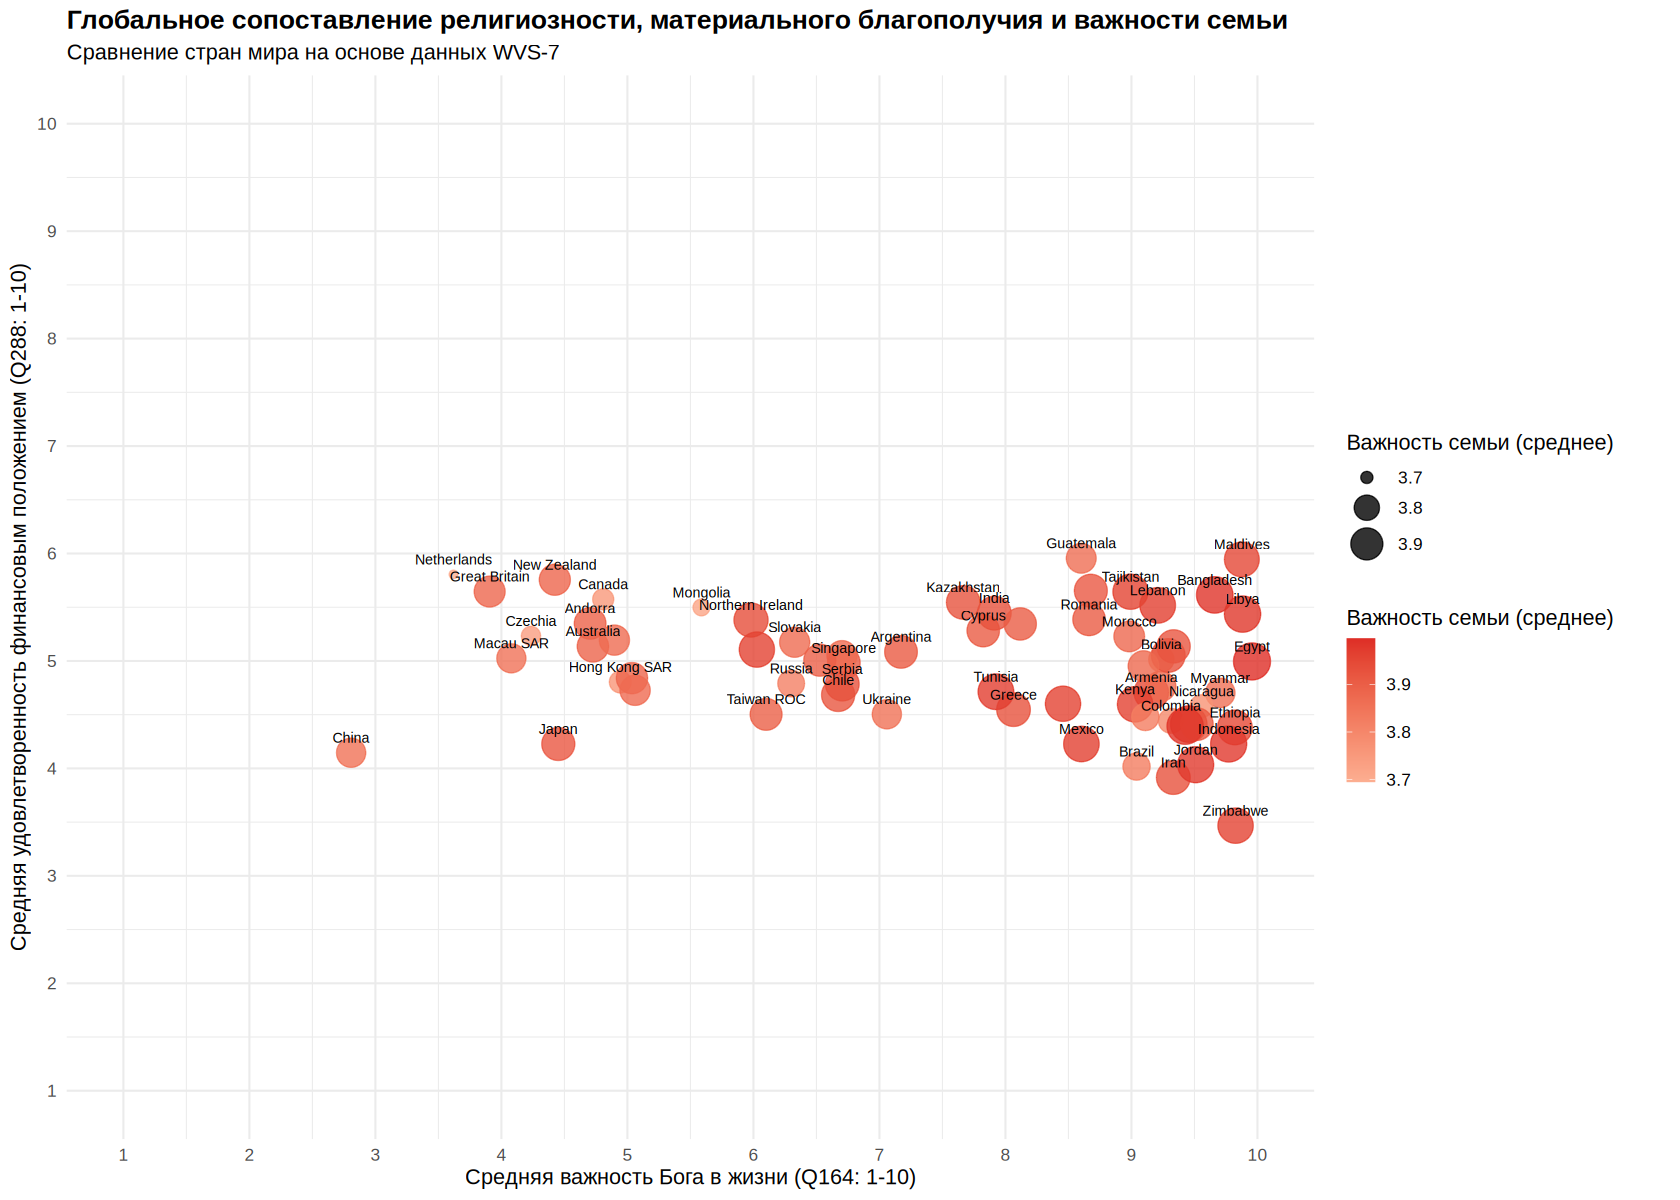

In [ ]:
library(dplyr)
library(haven)
library(ggplot2)

# 1. Подготовка и очистка данных для всех стран
global_bubble_data <- wvs7 %>%
  mutate(
    Country_Label = as.character(as_factor(B_COUNTRY)),
    # Религиозность (Q164): 1-10
    God_Importance = as.numeric(zap_labels(Q164)),
    # Финансовая удовлетворенность (Q288): 1-10
    Financial_Sat = as.numeric(zap_labels(Q288)),
    # Важность семьи (Q1): 1 - Very important, 4 - Not at all important.
    # Инвертируем, чтобы большее значение (и больший пузырек) означало большую важность:
    Family_Importance = 5 - as.numeric(zap_labels(Q1))
  ) %>%
  filter(
    !is.na(God_Importance) & God_Importance >= 1 & God_Importance <= 10,
    !is.na(Financial_Sat) & Financial_Sat >= 1 & Financial_Sat <= 10,
    !is.na(Family_Importance) & Family_Importance >= 1 & Family_Importance <= 4
  )

# 2. Агрегация на уровне стран
global_bubble_summary <- global_bubble_data %>%
  group_by(Country_Label) %>%
  summarise(
    Mean_God_Importance = mean(God_Importance),
    Mean_Financial_Sat = mean(Financial_Sat),
    Mean_Family_Imp = mean(Family_Importance),
    N = n(),
    .groups = "drop"
  ) %>%
  # Исключаем страны с маленькой выборкой
  filter(N >= 100)

# 3. Построение глобальной пузырьковой диаграммы
options(repr.plot.width = 14, repr.plot.height = 10)

p_global_bubble <- ggplot(global_bubble_summary, aes(x = Mean_God_Importance, y = Mean_Financial_Sat)) +
  geom_point(aes(size = Mean_Family_Imp, color = Mean_Family_Imp), alpha = 0.8) +
  # Используем стандартный geom_text с фильтрацией наложений
  geom_text(aes(label = Country_Label), size = 3, vjust = -1, check_overlap = TRUE) +
  scale_color_gradient(low = "#fcae91", high = "#de2d26") +
  scale_size_continuous(range = c(2, 10)) +
  scale_x_continuous(limits = c(1, 10), breaks = 1:10) +
  scale_y_continuous(limits = c(1, 10), breaks = 1:10) +
  theme_minimal(base_size = 13) +
  labs(
    title = "Глобальное сопоставление религиозности, материального благополучия и важности семьи",
    subtitle = "Сравнение стран мира на основе данных WVS-7",
    x = "Средняя важность Бога в жизни (Q164: 1-10)",
    y = "Средняя удовлетворенность финансовым положением (Q288: 1-10)",
    size = "Важность семьи (среднее)",
    color = "Важность семьи (среднее)"
  ) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    legend.position = "right"
  )

print(p_global_bubble)

# 4. Сохранение графика
ggsave("global_relig_finance_family_bubble.png", plot = p_global_bubble, width = 14, height = 10, dpi = 300)

In [ ]:
# выборка Сербия и Чехия с блоками: доверие, семья, религиозность

wvs7 <- readRDS("WVS_Cross-National_Wave_7_rds_v6_0.rds")

# Для работы с типами haven_labelled подключим библиотеку haven или снимем метки
library(haven)

final_df <- wvs7 %>%
  filter(as.numeric(zap_labels(B_COUNTRY)) %in% c(688, 203)) %>%
  select(
    B_COUNTRY, W_WEIGHT,
    # Доверие
    Q57, Q58, Q59, Q60, Q61, Q62, Q63, Q64, Q65, Q69, Q70,
    # Семья
    Q1, Q11, Q17, Q31, Q32, Q33, Q45, Q182, Q184,
    # Религиозность
    Q6, Q164, Q165, Q166, Q171, Q172, Q173, Q175, Q289,
    # Социально-демографические
    Q260, Q261, Q262, Q273, Q274, Q275, Q279, Q287, Q288, Q290
  )

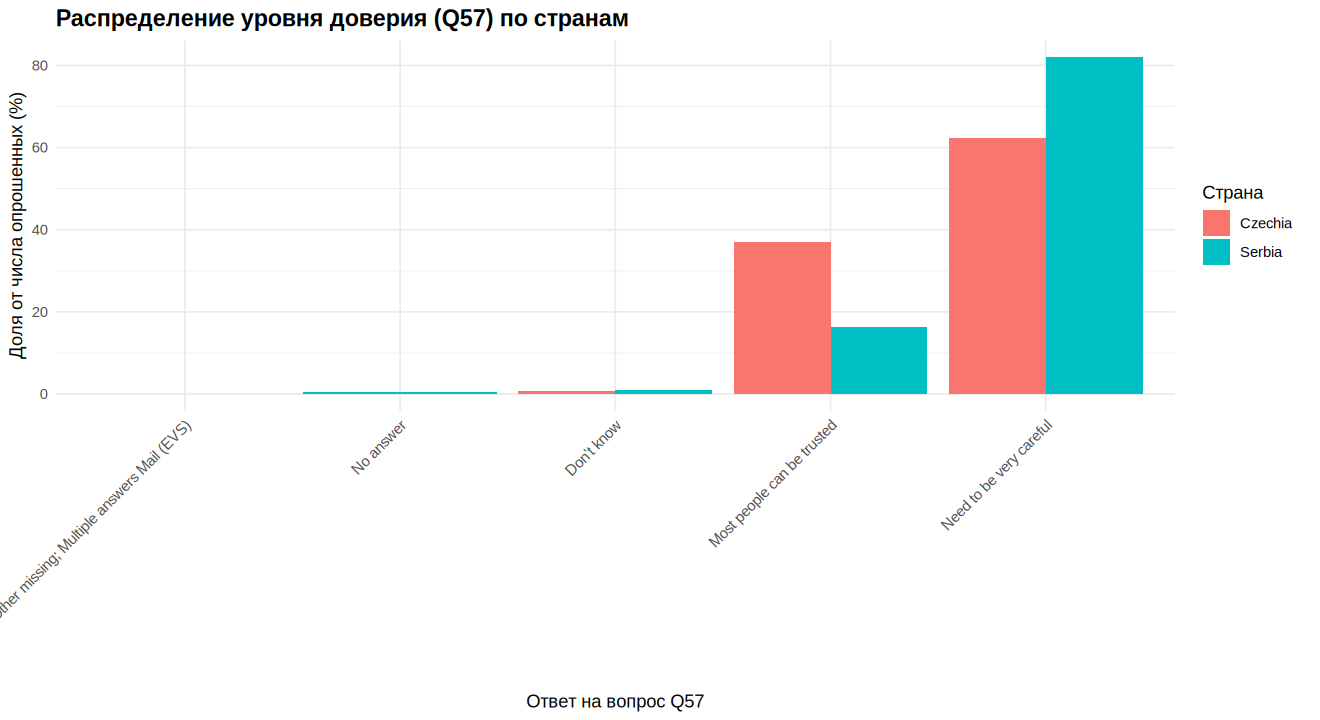

In [ ]:
# Распределение ответов на вопрос о доверии по двум странам

library(ggplot2)
library(dplyr)

# Подготовка данных с расчетом долей
plot_df <- final_df %>%
  mutate(
    Country_Name = ifelse(as.numeric(zap_labels(B_COUNTRY)) == 688, "Serbia", "Czechia"),
    Trust_Level = as_factor(Q57)
  ) %>%
  filter(!is.na(Trust_Level)) %>%
  # Группируем по странам и ответам, чтобы посчитать доли
  count(Country_Name, Trust_Level) %>%
  group_by(Country_Name) %>%
  mutate(Percentage = n / sum(n) * 100) %>%
  ungroup()

# Построение графика долей
ggplot(plot_df, aes(x = Trust_Level, y = Percentage, fill = Country_Name)) +
  geom_col(position = "dodge") +
  theme_minimal() +
  labs(
    title = "Распределение уровня доверия (Q57) по странам",
    x = "Ответ на вопрос Q57",
    y = "Доля от числа опрошенных (%)",
    fill = "Страна"
  ) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(face = "bold", size = 14)
  )

In [ ]:
# проверим достоверность различий

# Очищаем данные от неиспользуемых уровней и категорий пропусков для Q57
test_df <- final_df %>%
  mutate(
    Country_Name = ifelse(as.numeric(zap_labels(B_COUNTRY)) == 688, "Serbia", "Czechia"),
    Trust_Level = as_factor(Q57)
  ) %>%
  # Оставляем только основные осмысленные ответы
  filter(Trust_Level %in% c("Most people can be trusted", "Need to be very careful")) %>%
  mutate(Trust_Level = droplevels(Trust_Level))

# Построение таблицы сопряженности
contingency_table <- table(test_df$Country_Name, test_df$Trust_Level)
print("Таблица сопряженности (очищенные частоты):")
print(contingency_table)

# Проведение теста Хи-квадрат
chi2_test <- chisq.test(contingency_table)
print("Результаты теста Хи-квадрат Пирсона:")
print(chi2_test)

[1] "Таблица сопряженности (очищенные частоты):"
         
          Most people can be trusted Need to be very careful
  Czechia                        444                     747
  Serbia                         171                     858
[1] "Результаты теста Хи-квадрат Пирсона:"

	Pearson's Chi-squared test with Yates' continuity correction

data:  contingency_table
X-squared = 116.64, df = 1, p-value < 2.2e-16



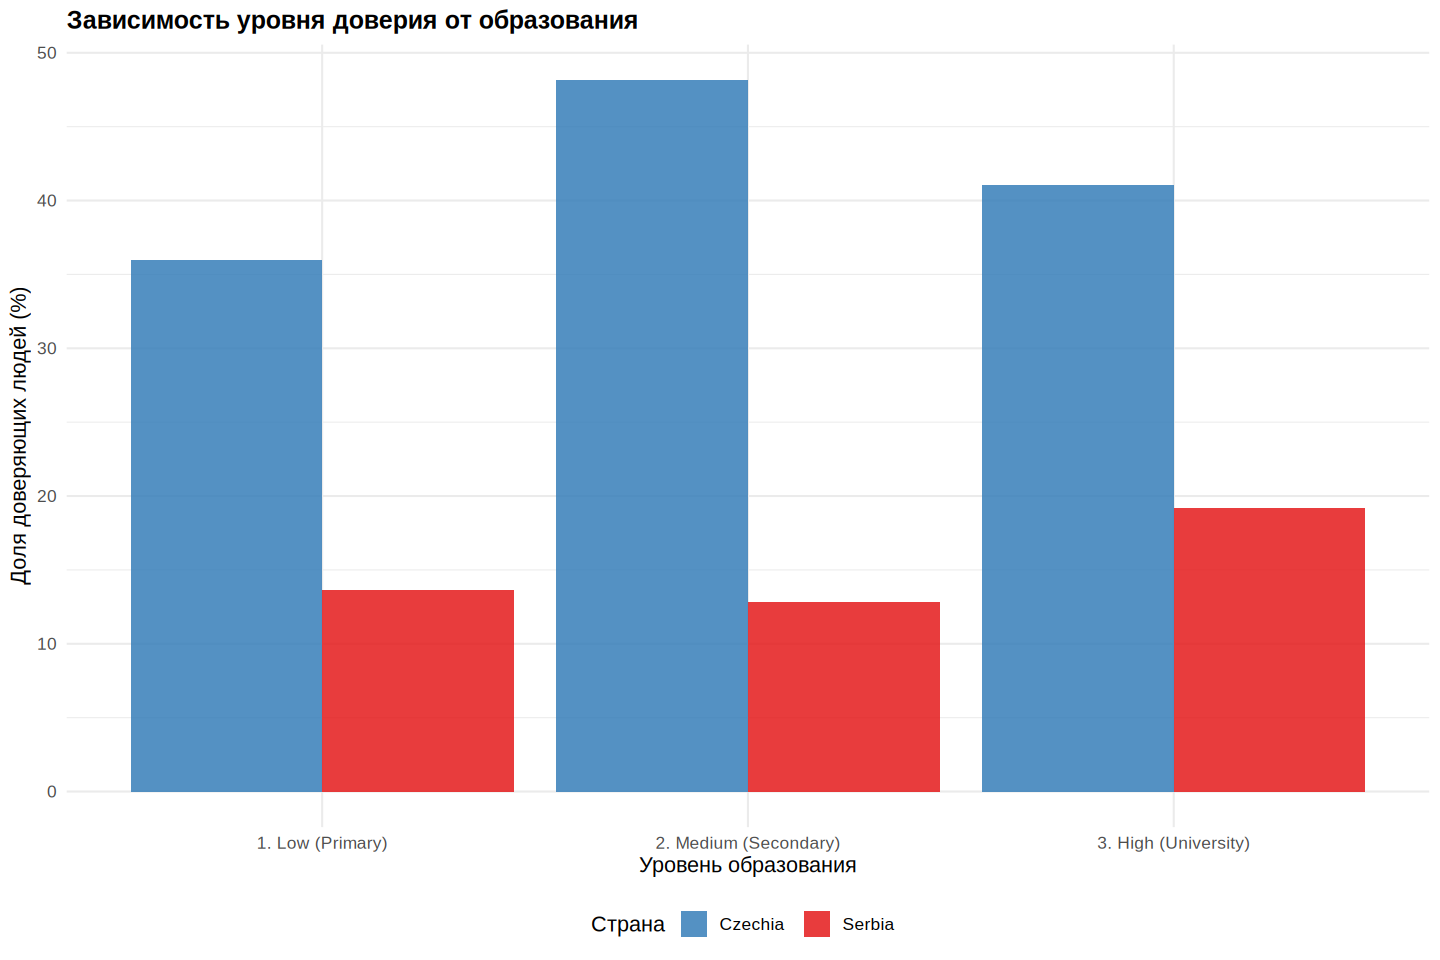

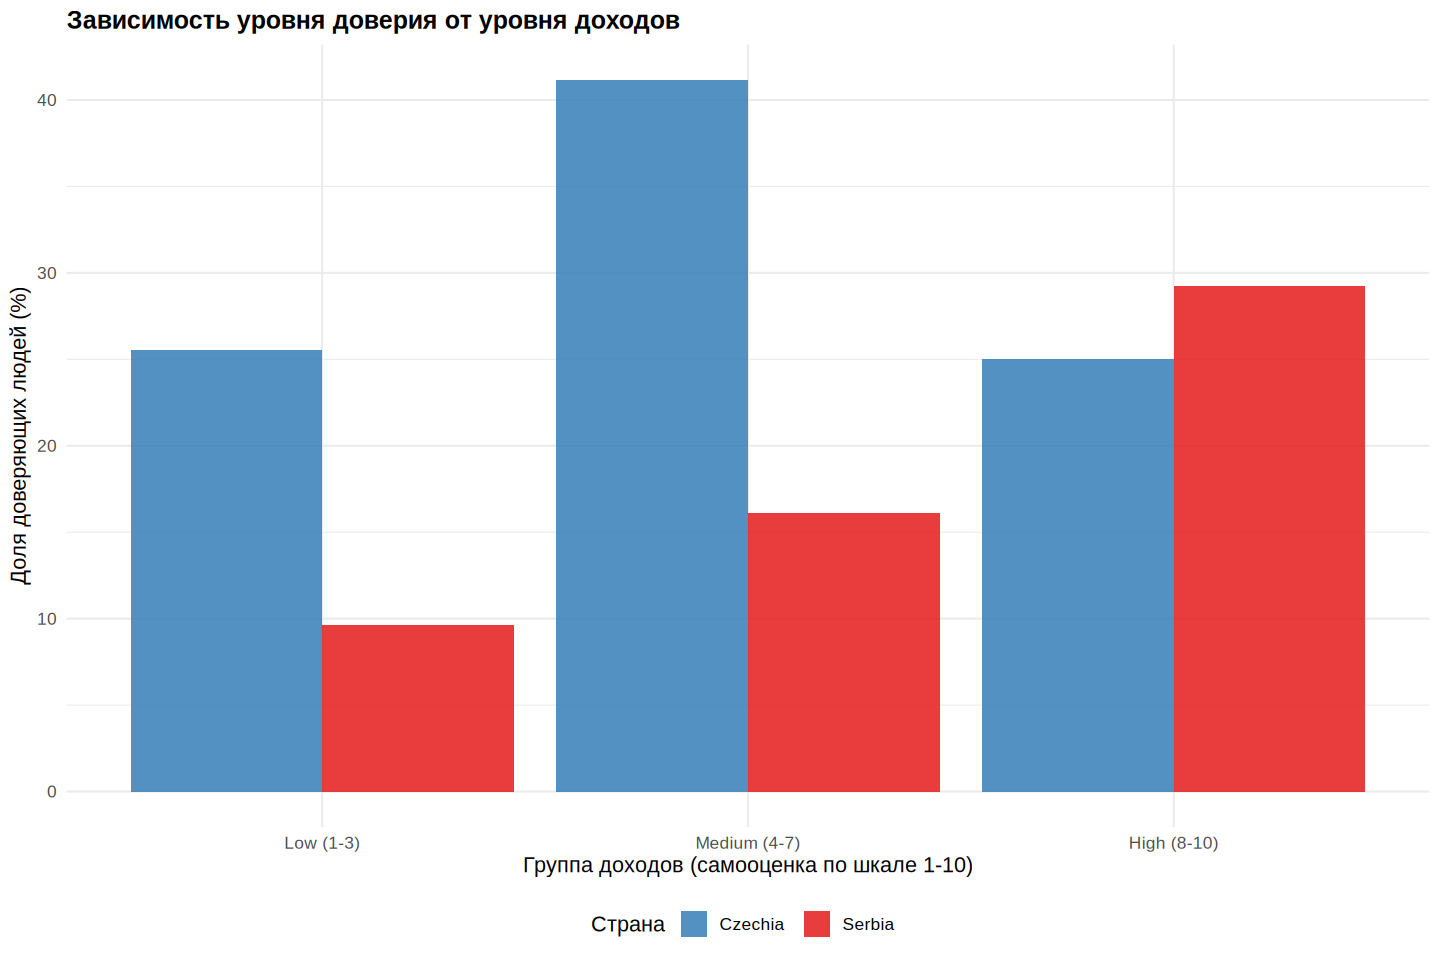

In [ ]:
library(dplyr)
library(haven)
library(ggplot2)
library(tidyr)

# 1. Подготовка данных: образование и доход
socio_trust_df <- wvs7 %>%
  filter(as.numeric(zap_labels(B_COUNTRY)) %in% c(688, 203)) %>%
  mutate(
    Country_Name = ifelse(as.numeric(zap_labels(B_COUNTRY)) == 688, "Serbia", "Czechia"),
    # Q57: 1 - Most people can be trusted, 2 - Need to be very careful
    Trust_Bin = ifelse(as.numeric(zap_labels(Q57)) == 1, 1, 0),
    # Q275 (Образование): преобразуем в фактор с укрупненными категориями
    # Обычно: 1-3 - Низкое (начальное), 4-5 - Среднее, 6-8 - Высшее/специальное
    Edu_Code = as.numeric(zap_labels(Q275)),
    Education = case_when(
      Edu_Code %in% 1:3 ~ "1. Low (Primary)",
      Edu_Code %in% 4:5 ~ "2. Medium (Secondary)",
      Edu_Code %in% 6:8 ~ "3. High (University)",
      TRUE ~ NA_character_
    ),
    # Q288 (Шкала доходов): от 1 до 10. Разобьем на три группы (низкий 1-3, средний 4-7, высокий 8-10)
    Income_Code = as.numeric(zap_labels(Q288)),
    Income_Group = case_when(
      Income_Code %in% 1:3 ~ "Low (1-3)",
      Income_Code %in% 4:7 ~ "Medium (4-7)",
      Income_Code %in% 8:10 ~ "High (8-10)",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(
    !is.na(Education),
    !is.na(Income_Group),
    as.numeric(zap_labels(Q57)) > 0
  )

# --- АНАЛИЗ ПО УРОВНЮ ОБРАЗОВАНИЯ ---
edu_summary <- socio_trust_df %>%
  group_by(Country_Name, Education) %>%
  summarise(
    Trust_Pct = mean(Trust_Bin) * 100,
    N = n(),
    .groups = 'drop'
  )

# Построение графика зависимости доверия от образования
p_edu <- ggplot(edu_summary, aes(x = Education, y = Trust_Pct, fill = Country_Name)) +
  geom_col(position = "dodge", alpha = 0.85) +
  scale_fill_manual(values = c("Serbia" = "#E41A1C", "Czechia" = "#377EB8")) +
  theme_minimal(base_size = 13) +
  labs(
    title = "Зависимость уровня доверия от образования",
    x = "Уровень образования",
    y = "Доля доверяющих людей (%)",
    fill = "Страна"
  ) +
  theme(
    plot.title = element_text(face = "bold", size = 15),
    legend.position = "bottom"
  )

print(p_edu)

ggsave("trust_by_education.png", plot = p_edu, width = 10, height = 6, dpi = 300)

# --- АНАЛИЗ ПО УРОВНЮ ДОХОДА ---
income_summary <- socio_trust_df %>%
  group_by(Country_Name, Income_Group) %>%
  summarise(
    Trust_Pct = mean(Trust_Bin) * 100,
    N = n(),
    .groups = 'drop'
  ) %>%
  # Задаем порядок группам доходов
  mutate(Income_Group = factor(Income_Group, levels = c("Low (1-3)", "Medium (4-7)", "High (8-10)")))

p_income <- ggplot(income_summary, aes(x = Income_Group, y = Trust_Pct, fill = Country_Name)) +
  geom_col(position = "dodge", alpha = 0.85) +
  scale_fill_manual(values = c("Serbia" = "#E41A1C", "Czechia" = "#377EB8")) +
  theme_minimal(base_size = 13) +
  labs(
    title = "Зависимость уровня доверия от уровня доходов",
    x = "Группа доходов (самооценка по шкале 1-10)",
    y = "Доля доверяющих людей (%)",
    fill = "Страна"
  ) +
  theme(
    plot.title = element_text(face = "bold", size = 15),
    legend.position = "bottom"
  )

print(p_income)

ggsave("trust_by_income.png", plot = p_income, width = 10, height = 6, dpi = 300)


`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


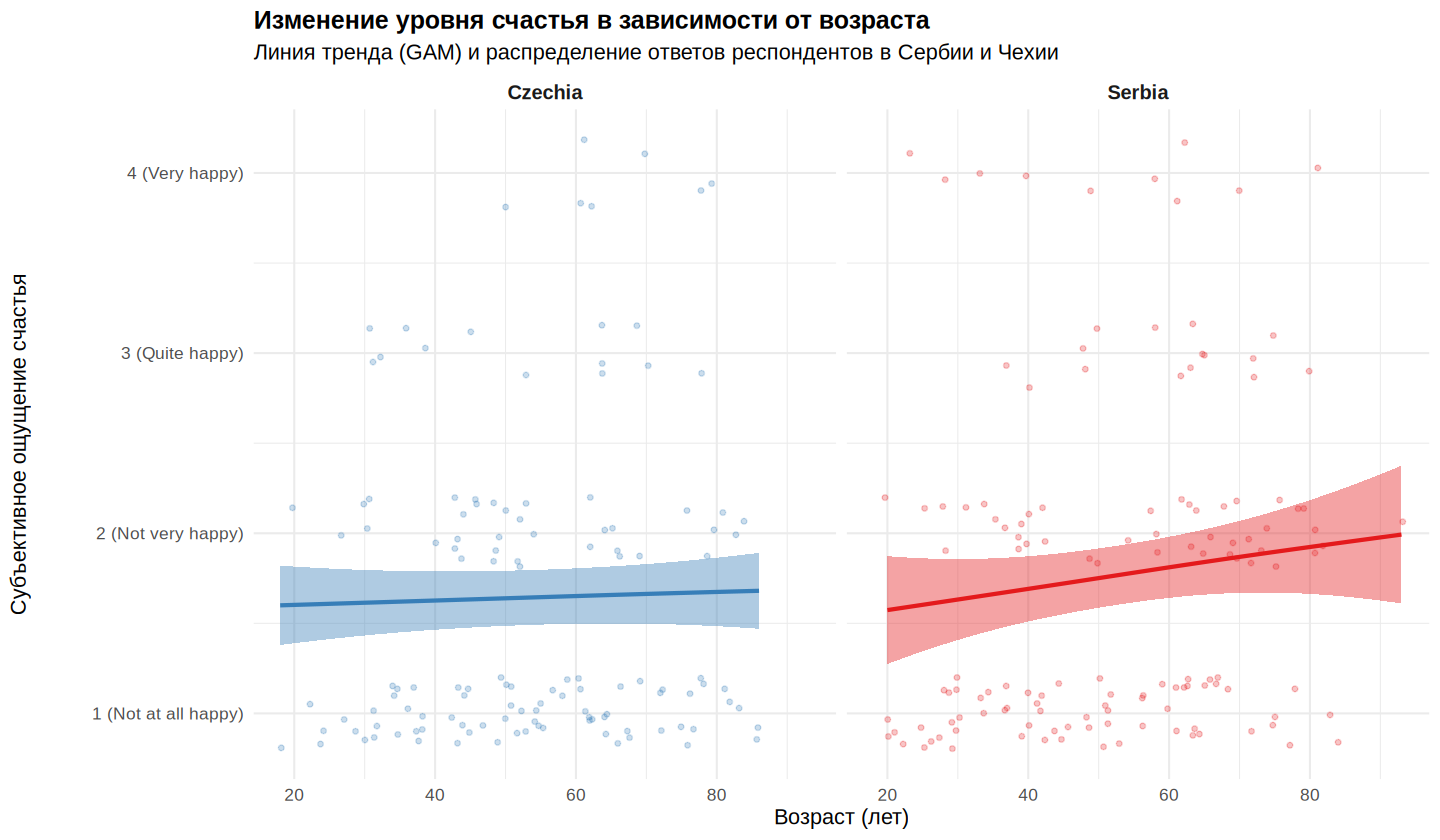

In [ ]:
library(ggplot2)
library(dplyr)
library(haven)

# 1. Подготовка данных: возраст и уровень счастья
happiness_age_df <- wvs7 %>%
  filter(as.numeric(zap_labels(B_COUNTRY)) %in% c(688, 203)) %>%
  mutate(
    Age = as.numeric(zap_labels(Q262)),
    # Инвертируем шкалу Q49: 4 - Очень счастлив, 1 - Совсем не счастлив
    Happiness = 5 - as.numeric(zap_labels(Q49)),
    Country_Name = ifelse(as.numeric(zap_labels(B_COUNTRY)) == 688, "Serbia", "Czechia")
  ) %>%
  filter(
    !is.na(Age) & Age > 0,
    !is.na(Happiness) & Happiness >= 1 & Happiness <= 4
  )

# 2. Построение графика
p_trend <- ggplot(happiness_age_df, aes(x = Age, y = Happiness, color = Country_Name)) +
  geom_jitter(alpha = 0.25, width = 0.4, height = 0.2, size = 1.2) +
  geom_smooth(method = "gam", aes(fill = Country_Name), size = 1.2, se = TRUE) +
  facet_wrap(~Country_Name) +
  scale_color_manual(values = c("Serbia" = "#E41A1C", "Czechia" = "#377EB8")) +
  scale_fill_manual(values = c("Serbia" = "#E41A1C", "Czechia" = "#377EB8")) +
  scale_y_continuous(
    breaks = 1:4,
    labels = c("1 (Not at all happy)", "2 (Not very happy)", "3 (Quite happy)", "4 (Very happy)")
  ) +
  theme_minimal(base_size = 13) +
  labs(
    title = "Изменение уровня счастья в зависимости от возраста",
    subtitle = "Линия тренда (GAM) и распределение ответов респондентов в Сербии и Чехии",
    x = "Возраст (лет)",
    y = "Субъективное ощущение счастья"
  ) +
  theme(
    plot.title = element_text(face = "bold", size = 15),
    legend.position = "none",
    strip.text = element_text(face = "bold", size = 12)
  )

print(p_trend)

# 3. Сохранение графика
ggsave("happiness_vs_age_trend.png", plot = p_trend, width = 11, height = 6, dpi = 300)


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


[1] "График успешно сохранен под именем 'age_vs_wellbeing_comparison.png'"


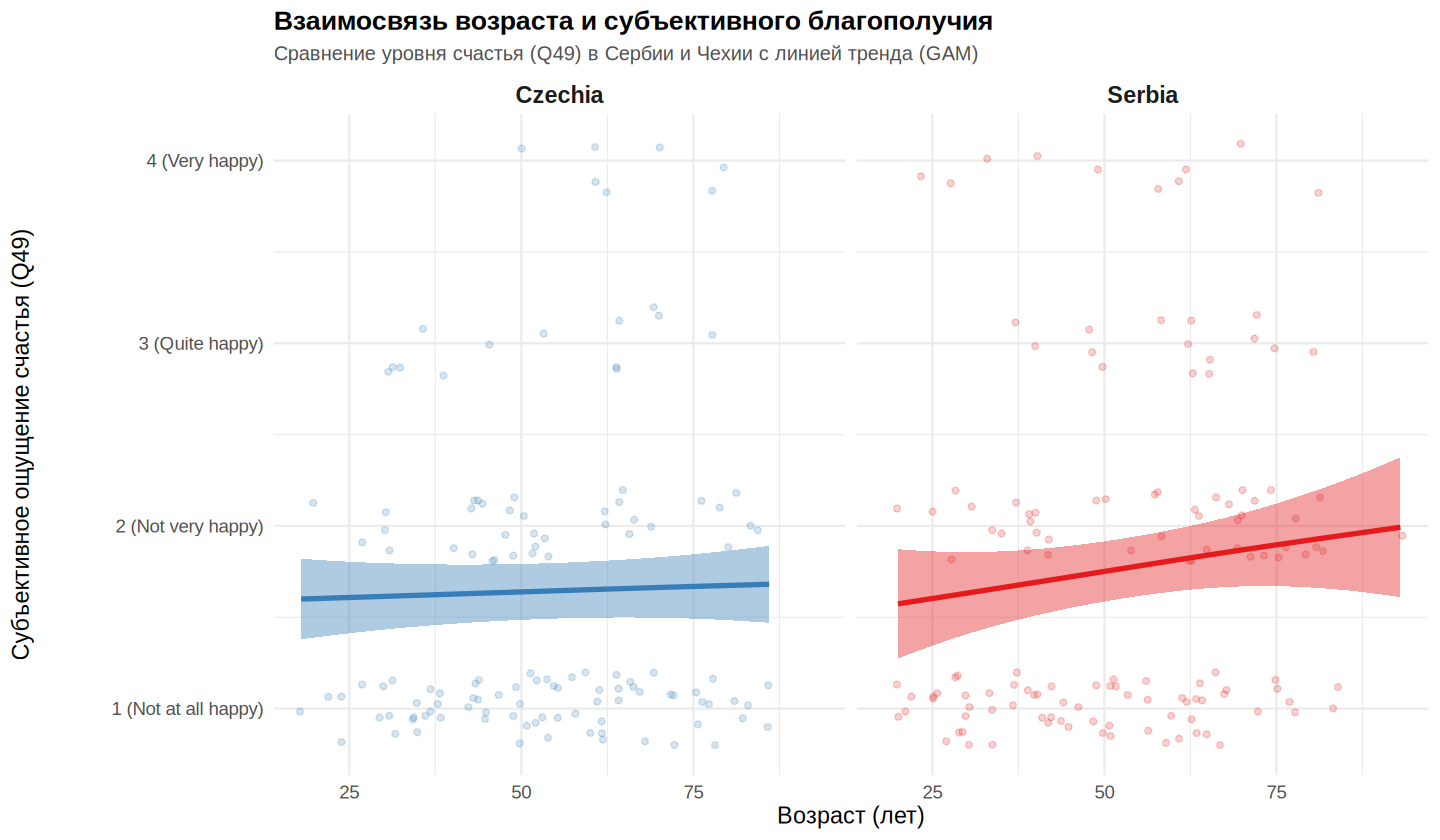

In [ ]:
library(ggplot2)
library(dplyr)
library(haven)

# 1. Подготовка данных из исходного wvs7, чтобы избежать отсутствия колонок в final_df
wellbeing_df <- wvs7 %>%
  filter(as.numeric(zap_labels(B_COUNTRY)) %in% c(688, 203)) %>%
  mutate(
    Age = as.numeric(zap_labels(Q262)),
    # Q49: Feeling of happiness (1 - Very happy, 2 - Quite happy, 3 - Not very happy, 4 - Not at all happy)
    # Для наглядности инвертируем шкалу, чтобы больший балл означал большее благополучие:
    # 4 - Очень счастлив, 1 - Совсем не счастлив
    Happiness = 5 - as.numeric(zap_labels(Q49)),
    Country_Name = ifelse(as.numeric(zap_labels(B_COUNTRY)) == 688, "Serbia", "Czechia")
  ) %>%
  filter(
    !is.na(Age) & Age > 0,
    !is.na(Happiness) & Happiness >= 1 & Happiness <= 4
  )

# 2. Построение графика увеличенного размера
options(repr.plot.width = 12, repr.plot.height = 7)

p <- ggplot(wellbeing_df, aes(x = Age, y = Happiness, color = Country_Name)) +
  # Легкий джиттер для отображения плотности точек
  geom_jitter(alpha = 0.2, width = 0.4, height = 0.2, size = 1.5) +
  # Сглаженная линия тренда (метод Generalized Additive Model)
  geom_smooth(method = "gam", se = TRUE, size = 1.5, aes(fill = Country_Name)) +
  facet_wrap(~Country_Name) +
  scale_color_manual(values = c("Serbia" = "#E41A1C", "Czechia" = "#377EB8")) +
  scale_fill_manual(values = c("Serbia" = "#E41A1C", "Czechia" = "#377EB8")) +
  scale_y_continuous(
    breaks = 1:4,
    labels = c("1 (Not at all happy)", "2 (Not very happy)", "3 (Quite happy)", "4 (Very happy)")
  ) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Взаимосвязь возраста и субъективного благополучия",
    subtitle = "Сравнение уровня счастья (Q49) в Сербии и Чехии с линией тренда (GAM)",
    x = "Возраст (лет)",
    y = "Субъективное ощущение счастья (Q49)",
    color = "Страна",
    fill = "Страна"
  ) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    plot.subtitle = element_text(size = 12, color = "gray30"),
    legend.position = "none",
    strip.text = element_text(face = "bold", size = 14)
  )

# Отображаем график в блокноте
print(p)

# 3. Сохранение графика в файл высокого разрешения
ggsave(
  filename = "age_vs_wellbeing_comparison.png",
  plot = p,
  width = 12,
  height = 7,
  dpi = 300
)

print("График успешно сохранен под именем 'age_vs_wellbeing_comparison.png'")

In [ ]:
# Давай представим эти же данные в виде таблицы по странам: возрастная группа и средний уровень счастья

In [ ]:
library(dplyr)
library(haven)
library(tidyr)

# 1. Подготовка данных с разбивкой на возрастные группы
age_groups_happiness <- wvs7 %>%
  filter(as.numeric(zap_labels(B_COUNTRY)) %in% c(688, 203)) %>%
  mutate(
    Country = ifelse(as.numeric(zap_labels(B_COUNTRY)) == 688, "Serbia", "Czechia"),
    Age = as.numeric(zap_labels(Q262)),
    # Инвертируем шкалу счастья (Q49): 4 - Очень счастлив, 1 - Совсем не счастлив
    Happiness = 5 - as.numeric(zap_labels(Q49))
  ) %>%
  filter(
    !is.na(Age) & Age > 0 & Age < 110,
    !is.na(Happiness) & Happiness >= 1 & Happiness <= 4
  ) %>%
  # Классифицируем по возрастным группам
  mutate(
    Age_Group = case_when(
      Age < 30 ~ "1. Under 30",
      Age >= 30 & Age <= 44 ~ "2. 30-44 years",
      Age >= 45 & Age <= 59 ~ "3. 45-59 years",
      Age >= 60 ~ "4. 60+ years"
    )
  )

# 2. Агрегация данных и расчет среднего уровня счастья
happiness_table <- age_groups_happiness %>%
  group_by(Country, Age_Group) %>%
  summarise(
    `Средний уровень счастья (1-4)` = round(mean(Happiness), 3),
    `Размер выборки (N)` = n(),
    .groups = "drop"
  ) %>%
  # Развернем таблицу для удобного сравнения стран
  pivot_wider(
    names_from = Country,
    values_from = c(`Средний уровень счастья (1-4)`, `Размер выборки (N)`)
  ) %>%
  select(
    `Возрастная группа` = Age_Group,
    `Счастье: Чехия` = `Средний уровень счастья (1-4)_Czechia`,
    `N: Чехия` = `Размер выборки (N)_Czechia`,
    `Счастье: Сербия` = `Средний уровень счастья (1-4)_Serbia`,
    `N: Сербия` = `Размер выборки (N)_Serbia`
  )

# Вывод итоговой таблицы
print(happiness_table)


# A tibble: 4 × 5
  `Возрастная группа` `Счастье: Чехия` `N: Чехия` `Счастье: Сербия` `N: Сербия`
  <chr>                          <dbl>      <int>             <dbl>       <int>
1 1. Under 30                     1.25          8              1.56          18
2 2. 30-44 years                  1.58         33              1.62          34
3 3. 45-59 years                  1.54         35              1.74          27
4 4. 60+ years                    1.81         53              1.93          57


In [ ]:
library(dplyr)
library(haven)

# 1. Подготовка данных с учетом пола (Q260)
gender_happiness_df <- wvs7 %>%
  filter(as.numeric(zap_labels(B_COUNTRY)) %in% c(688, 203)) %>%
  mutate(
    Country = ifelse(as.numeric(zap_labels(B_COUNTRY)) == 688, "Serbia", "Czechia"),
    Age = as.numeric(zap_labels(Q262)),
    # Q49: Инвертируем шкалу счастья: 4 - Очень счастлив, 1 - Совсем не счастлив
    Happiness = 5 - as.numeric(zap_labels(Q49)),
    # Q260: 1 - Male, 2 - Female
    Gender = case_when(
      as.numeric(zap_labels(Q260)) == 1 ~ "Male",
      as.numeric(zap_labels(Q260)) == 2 ~ "Female",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(
    !is.na(Age) & Age > 0,
    !is.na(Happiness) & Happiness >= 1 & Happiness <= 4,
    !is.na(Gender)
  )

# 2. Расчет корреляций по группам
correlations_by_gender <- gender_happiness_df %>%
  group_by(Country, Gender) %>%
  summarise(
    `Pearson r` = round(cor(Age, Happiness, method = "pearson"), 4),
    `Pearson p-value` = format.pval(cor.test(Age, Happiness, method = "pearson")$p.value, digits = 4),
    `Spearman rho` = round(cor(Age, Happiness, method = "spearman"), 4),
    `Spearman p-value` = format.pval(cor.test(Age, Happiness, method = "spearman")$p.value, digits = 4),
    `N` = n(),
    .groups = "drop"
  )

# Вывод результатов
print(correlations_by_gender)


Warning message:
“There were 4 warnings in `summarise()`.
The first warning was:
ℹ In argument: `Spearman p-value = format.pval(...)`.
ℹ In group 1: `Country = "Czechia"`, `Gender = "Female"`.
Caused by warning in `cor.test.default()`:
! cannot compute exact p-value with ties
ℹ Run `dplyr::last_dplyr_warnings()` to see the 3 remaining warnings.”


# A tibble: 4 × 7
  Country Gender `Pearson r` `Pearson p-value` `Spearman rho` `Spearman p-value`
  <chr>   <chr>        <dbl> <chr>                      <dbl> <chr>             
1 Czechia Female      0.0587 0.6346                    0.0251 0.839             
2 Czechia Male        0.17   0.1902                    0.126  0.3324            
3 Serbia  Female      0.104  0.3888                    0.135  0.2616            
4 Serbia  Male        0.244  0.05064                   0.288  0.02005           
# ℹ 1 more variable: N <int>
